In [27]:
import os
import operator
from typing import Annotated, Literal
from pydantic import BaseModel
from tavily import TavilyClient
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()

print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [3]:
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [ ]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_tool_use",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

print("Vector store ready")

In [6]:
llm = ChatOpenAI(model="gpt-5-mini")        # route_question and generate

agent_llm = ChatOpenAI(model="gpt-5-mini")  # agent node; tools bound later

In [7]:
class AgenticRAGState(MessagesState):

    query: str
    retrieved_docs: Annotated[list[Document], operator.add]
    context: Annotated[str, operator.add]
    generation: str
    needs_retrieval: bool

In [8]:
class RouteDecision(BaseModel):

    needs_retrieval: bool

In [9]:
@tool(response_format="content_and_artifact")
def vector_store_search(query: str, k: int = 3):
    """Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages."""
    
    docs = vectorstore.similarity_search(query, k=k)
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in docs)
    
    return context, docs

In [29]:
@tool(response_format="content_and_artifact")
def web_search(query: str, max_results: int = 3):
    """Search the web for current or real-time information.
    Adjust max_results (default 3) to control how many results are returned."""
    
    client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    response = client.search(query, max_results=max_results)
    
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]
    content = "\n\n## Web Search Results\n\n" + "\n\n".join(d.page_content for d in docs)
    return content, docs

In [30]:
tools = [vector_store_search, web_search]

agent_llm_with_tools = agent_llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [31]:
# route_question node — classifies whether the query needs retrieval
def route_question(state: AgenticRAGState) -> dict:

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])

    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})

    return {"needs_retrieval": decision.needs_retrieval}

In [32]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools."
)

# agent node — decides which tool(s) to call based on the query
def agent(state: AgenticRAGState) -> dict:

    messages = state["messages"]
    if not messages:
        messages = [SystemMessage(content=AGENT_SYSTEM_PROMPT),
                    HumanMessage(content=state["query"])]

    response = agent_llm_with_tools.invoke(messages)

    return {"messages": [response]}

In [33]:
# collect_tool_output node — drains ToolMessages into state fields
def collect_tool_output(state: AgenticRAGState) -> dict:

    tool_messages = [m for m in state["messages"] if isinstance(m, ToolMessage)]
    all_docs, context_parts = [], []

    for msg in tool_messages:
        context_parts.append(msg.content)
        all_docs.extend(msg.artifact)

    return {
        "context": "\n\n".join(context_parts),
        "retrieved_docs": all_docs,
    }

In [34]:
# generate node — produces the final answer with or without retrieved context
def generate(state: AgenticRAGState) -> dict:

    query = state["query"]
    context = state.get("context") or ""

    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"context": context, "query": query})

    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [35]:
def route_after_classification(state: AgenticRAGState) -> Literal["agent", "generate"]:
    return "agent" if state["needs_retrieval"] else "generate"

def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    return "tools" if state["messages"][-1].tool_calls else "collect_tool_output"

In [36]:
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("route_question", route_question)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "route_question")
graph_builder.add_conditional_edges("route_question", route_after_classification)
graph_builder.add_conditional_edges("agent", route_after_agent)
graph_builder.add_edge("tools", "agent")
graph_builder.add_edge("collect_tool_output", "generate")
graph_builder.add_edge("generate", END)

In [37]:
graph = graph_builder.compile()

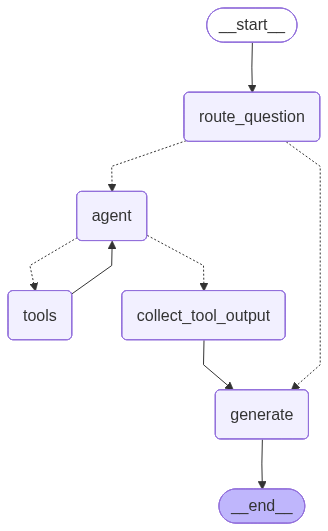

In [38]:
graph

In [20]:
# Case 1: vector store only — domain-specific question about the PDF
query_vs = "According to the report, how will the adoption of electric vehicles impact oil demand?"

result_vs = graph.invoke({"query": query_vs, "messages": [], "retrieved_docs": [], "context": ""})

In [21]:
print("=== CASE 1: Vector Store Only ===")
print(f"needs_retrieval : {result_vs['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_vs.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_vs.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_vs['generation']}")

=== CASE 1: Vector Store Only ===
needs_retrieval : True
retrieved_docs  : 8 docs
context preview : 

## Vector Store Results

Energy Agency, and McKinsey collectively project that EVs will account for between 40 and
60 ...

Generation:
In short: EV adoption will reduce oil demand but relatively gradually and only partially.

Key points from the report:
- EVs directly displace liquid fuel consumption (demand destruction): each EV replaces roughly 560 liters of gasoline per year (about 1 barrel of oil per month).
- Under a high-adoption pathway (≈300 million EVs by 2030), the report estimates roughly 4.6 million barrels per day of oil displaced by 2030 — meaningful but small against a ~100–105 mbpd global demand base.
- Passenger vehicle electrification targets a segment that represents about one-quarter of global oil demand (passenger cars ≈26 mbpd; light commercial ≈7–8 mbpd). Heavy trucking, aviation, shipping and petrochemicals (together ≈43% of consumption) are much harder to elect

In [23]:
print(result_vs["context"])



## Vector Store Results

Energy Agency, and McKinsey collectively project that EVs will account for between 40 and
60 percent of new vehicle sales globally by 2030. The stock of EVs on the road — which
matters more than annual sales for oil displacement — is projected to grow from roughly 40
million vehicles today to between 300 and 500 million by the early 2030s. Whether this is
sufficient to materially alter the oil price formation process is the central question this report
addresses.
1.1 Scope and Methodology
 This report focuses on the relationship between passenger and light commercial vehicle
electrification and global oil demand dynamics. Heavy trucking, aviation, shipping, and
petrochemical feedstock demand — which collectively account for roughly 43 percent of oil
consumption — are not the primary subject of analysis, though their trajectories are

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 8
4. EV Adoption T

In [39]:
# Case 2: web search only — current information not in the PDF
query_web = "What is the current temperature in New Delhi?"

result_web = graph.invoke({"query": query_web, "messages": [], "retrieved_docs": [], "context": ""})

In [40]:
print("=== CASE 2: Web Search Only ===")
print(f"needs_retrieval : {result_web['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_web.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_web.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_web['generation']}")

=== CASE 2: Web Search Only ===
needs_retrieval : True
retrieved_docs  : 20 docs
context preview : 

## Web Search Results

Current New Delhi weather condition is Mist with real-time temperature (33°C), humidity 32%, wi...

Generation:
The current temperature in New Delhi is 33°C (per the provided data).


In [47]:
# Case 3: both tools — requires document context AND current web data
query_both = "Compare what the EV report projects for 2030 oil demand with current oil demand due to Iran-US War."

result_both = graph.invoke({"query": query_both, "messages": [], "retrieved_docs": [], "context": ""})

In [48]:
print("=== CASE 3: Both Tools ===")
print(f"needs_retrieval : {result_both['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_both.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_both.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_both['generation']}")

=== CASE 3: Both Tools ===
needs_retrieval : True
retrieved_docs  : 10 docs
context preview : 

## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pi...

Generation:
I can’t produce a numeric, side‑by‑side comparison because the excerpts you provided do not include a specific 2030 oil‑demand number from the EV report nor a precise current global demand figure for the Iran–US war period. However, the materials do allow a clear qualitative comparison:

- EV report (from your context)
  - Does not claim large, economy‑wide demand relief by 2030. It emphasizes that meaningful oil‑price shock dampening from EVs will be “most pronounced after 2035” and that the 2024–2035 transition period may actually be one of elevated oil‑price risk.
  - Notes structural limits on rapid fleet turnover (global vehicle stock ~1.4 billion, ~90 million new vehicles/year, typical lifetimes 15–20+ years), implying only partial displacement of oil d

In [46]:
print(result_both["context"])



## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 8
4. EV Adoption Trajectories and Oil Demand Displacement
 Projecting oil demand displacement from EV adoption requires integrating three distinct
analytical layers: the annual sales trajectory for new EVs, the retirement rate of the existing
ICE fleet, and the average annual mileage and fuel economy of the vehicles being displaced.
The total stock of passenger vehicles globally stands at approximately 1.4 billion, the vast
majority of which are ICE vehicles. With global new vehicle sales of roughly 90 million units
per year and average vehicle lifetimes of 15 to 20 years in developed markets — and often
longer in developing markets — complete fleet electrification cannot occur in less than two to

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 3
Executive Summary
 The global transition towa

In [49]:
# Case 4: no retrieval — answerable from general knowledge
query_none = "Explain the difference between kinetic energy and potential energy."

result_none = graph.invoke({"query": query_none, "messages": [], "retrieved_docs": [], "context": ""})

In [50]:
print("=== CASE 4: No Retrieval ===")
print(f"needs_retrieval : {result_none['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_none.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_none.get('context', '') or '(none)'}")
print(f"\nGeneration:\n{result_none['generation']}")

=== CASE 4: No Retrieval ===
needs_retrieval : False
retrieved_docs  : 0 docs
context preview : (none)

Generation:
Kinetic energy and potential energy are two basic forms of mechanical energy. Key differences:

- What they depend on
  - Kinetic energy (KE) depends on motion — specifically on an object’s mass and speed. Formula for a non-rotating object: KE = 1/2 m v^2. Rotational kinetic energy: 1/2 I ω^2.
  - Potential energy (PE) depends on an object’s position or configuration in a force field (or its internal configuration). Examples: gravitational PE near Earth, PE = m g h; elastic (spring) PE, PE = 1/2 k x^2.

- Physical meaning
  - KE is the energy an object has because it is moving.
  - PE is stored energy that can be released as motion (or work) because of the object’s position, shape, or arrangement.

- Relation to forces
  - Potential energy is associated with conservative forces; it can be defined so that the force is the negative gradient of the potential: F = −∇U (or U =